# Model Analysis

---

## Introduction

In this notebook, we will analyze the performance of the models and will evaluate them on the test set and compare their performance. We will also analyze the errors made by the models to understand the limitations of the models and identify areas for improvement.

## A few necessary imports...

In [1]:
import os

import numpy as np
import pandas as pd
import dask.dataframe as dd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    classification_report,
)
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

## Time to Clean, Preprocess and Tokenize the Data!

We will start by cleaning the data and preprocessing it to make it suitable for training the models.

## Let's load the data using Dask

In [2]:
def find_csv_files(data_dir):
    csv_files = []
    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".csv"):
                csv_files.append(os.path.join(root, file))

    return sorted(csv_files)  # sorted for deterministic, reproducible ordering


def combine_csv_files(csv_files):
    dfs = []
    for csv_file in csv_files:
        df = dd.read_csv(csv_file, dtype=str, assume_missing=True)
        dfs.append(df)

    combined_dataframe = dd.concat(dfs, axis=0, interleave_partitions=True)

    return combined_dataframe


# Define the directory containing the CSV files
data_dir = "../db/data"

# Find all CSV files under the directory
csv_file_paths = find_csv_files(data_dir)

# Separate the CSV file paths into categories based on their names
attack_traffic_paths = [path for path in csv_file_paths if "attack_traffic" in path]
normal_traffic_paths = [path for path in csv_file_paths if "normal_traffic" in path]

# Combine CSV files for attack traffic and normal traffic using Dask
attack_traffic_dask = combine_csv_files(attack_traffic_paths)
normal_traffic_dask = combine_csv_files(normal_traffic_paths)

# Compute Dask DataFrames and convert them to pandas DataFrames
attack_traffic_df = attack_traffic_dask.compute()
normal_traffic_df = normal_traffic_dask.compute()

## Check the shape of the data

So we can get an idea of the size of the data.

In [3]:
attack_traffic_df_org_shape = attack_traffic_df.shape
normal_traffic_df_org_shape = normal_traffic_df.shape

print(f"Attack traffic original shape: {attack_traffic_df_org_shape}")
print(f"Normal traffic original shape: {normal_traffic_df_org_shape}")

Attack traffic original shape: (9729709, 63)
Normal traffic original shape: (11209913, 63)


## Let's define and drop some columns

These are some unnecessary flow features such as IP addresses, ports, timestamp and payload information, etc.

In [4]:
cols_to_drop = [
    "arp.dst.proto_ipv4",
    "arp.src.proto_ipv4",
    "frame.time",
    "http.file_data",
    "http.request.full_uri",
    "http.request.uri.query",
    "icmp.transmit_timestamp",
    "ip.dst_host",
    "ip.src_host",
    "mqtt.msg",
    "tcp.dstport",
    "tcp.options",
    "tcp.payload",
    "tcp.srcport",
    "udp.port",
]

attack_traffic_df.drop(columns=cols_to_drop, inplace=True)
normal_traffic_df.drop(columns=cols_to_drop, inplace=True)

## Stack the datasets and drop duplicates and missing values

Missing values and duplicates can cause problems in the training of the models. We will drop them to avoid any issues.

In [5]:
merged_traffic_df = pd.concat([attack_traffic_df, normal_traffic_df], ignore_index=True)
merged_traffic_df.dropna(inplace=True)
merged_traffic_df.drop_duplicates(inplace=True, keep="first")

## Sample the data to balance the classes

Balancing the classes is important to avoid the model from being biased towards the majority class. We will sample the data to balance the classes (we could also go a step further and stratify the data such that the classes are balanced in each fold of the cross-validation).

In [6]:
# Split DataFrames based on the traffic type
normal_traffic_df = merged_traffic_df[merged_traffic_df["Attack_label"] == "0"].sample(
    n=120_000, random_state=42
)
attack_traffic_df = merged_traffic_df[merged_traffic_df["Attack_label"] == "1"].sample(
    n=120_000, random_state=42
)

## Let's modify data types in preparation for encoding

In this step, we will convert the data types of the columns to make them suitable for encoding.

In [7]:
def modify_dtypes(df, categorical_columns):
    for column in df.columns:
        if column not in categorical_columns:
            df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0).astype(int)


# Define a list of categorical columns and cast columns in each dataframe (columns that give error get dropped)
categorical_columns = [
    "dns.qry.name.len",
    "http.referer",
    "http.request.method",
    "http.request.version",
    "mqtt.conack.flags",
    "mqtt.protoname",
    "mqtt.topic",
    "Attack_type",
]

# Concatenate the sampled DataFrames
balanced_sample_df = pd.concat(
    [attack_traffic_df, normal_traffic_df], ignore_index=True
)
modify_dtypes(balanced_sample_df, categorical_columns)

## Encode and shuffle the data

This is a necessary step to ensure that the model does not learn the order of the data. This is important because the data is sorted by the label, which can lead to the model learning the order of the data and not the features. We want to make sure that the model learns the features and not the order of the data.

In [8]:
def encode_categorical_columns(df, categorical_columns):
    return pd.get_dummies(
        df, columns=categorical_columns, prefix=categorical_columns, drop_first=False
    )


# Convert categorical columns into numeric values using one-hot encoding (dummy variables)
encoded_traffic_df = encode_categorical_columns(
    balanced_sample_df,
    [col for col in categorical_columns if col not in ["Attack_type"]],
)

# Shuffle the final DataFrame
shuffled_df = encoded_traffic_df.sample(frac=1, random_state=42)

## Split the data into training and testing sets

Our X (features) and y (labels) are ready. We will split the data into training and testing sets to train the models and evaluate them. We will use 80% of the data for training and 20% for testing. We will drop the label column from the test set to avoid data leakage.

In [9]:
# Split the dataset into training and testing sets
X = shuffled_df.drop(["Attack_label", "Attack_type"], axis=1)
y = shuffled_df["Attack_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_isattack = shuffled_df.loc[y_train.index]["Attack_label"]

# Scaling the data

We will scale the data to make sure that all the features are on the same scale. This is important because features that are on different scales can affect the performance of the model. We will use the StandardScaler to scale the data.

In [10]:
# Preprocess the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that is used to reduce the number of features in the data. It is used to reduce the dimensionality of the data by projecting it onto a lower-dimensional space. We will use PCA to reduce the number of features in the data and visualize the data in 2D. This will help us understand the data better and identify patterns in the data that can help us improve the performance of the models.

In [11]:
def pca_analysis(X_train, n_components=50, threshold=0.95):
    if isinstance(n_components, int):
        n_components = [n_components]
    pca = PCA(n_components=max(n_components))
    X_train_pca = pca.fit_transform(X_train)

    # Compute explained variances and cumulative explained variances
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    min_components = np.searchsorted(cumulative_variance, threshold) + 1

    # Print the fraction of total variance explained by the first k principal components
    print("Fraction of total variance explained by the first k principal components:")
    for n in n_components:
        pct = cumulative_variance[n - 1] * 100
        marker = f"  (meets the {threshold*100:.0f}% threshold)" if n >= min_components else ""
        print(f"{n} components: {pct:.2f}%{marker}")
    print(f"\n{min_components} components are needed to reach {threshold*100:.0f}% explained variance.")

    # Plot explained variance vs. number of principal components
    plt.plot(
        np.arange(1, len(cumulative_variance) + 1),
        cumulative_variance * 100,
        label="Cumulative Variance",
    )
    plt.axhline(y=threshold * 100, color="r", linestyle="-")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Percentage of Total Variance")
    plt.title("Explained Variance vs. Number of Principal Components")
    plt.legend()
    plt.show()

    return X_train_pca, min_components

The explained variance percentage indicates how much of the total variance in the dataset is captured by the principal components

- The first component explains about 10.02% of the variance.
- The top 5 components together explain approximately 29.8% of the variance.
- By the 10th component, we capture around 44.93% of the total variance.
- 45 components are needed to capture around 95.13% of the total variance.

Fraction of total variance explained by the first k principal components:
1 components: 10.02%
2 components: 16.00%
3 components: 21.11%
4 components: 25.84%
5 components: 29.89%
10 components: 44.93%
20 components: 64.01%
30 components: 77.01%
40 components: 89.68%
45 components: 95.13%  (meets the 95% threshold)

45 components are needed to reach 95% explained variance.


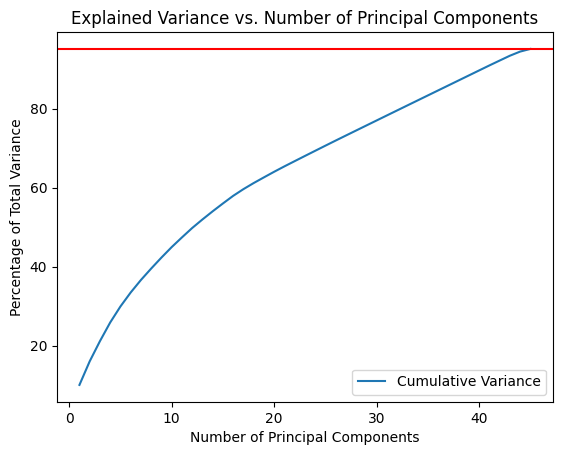

(array([[-3.35097256e+00,  5.30396969e-01,  3.29215459e+00, ...,
          2.20626449e-01,  2.70258239e-01, -1.41030568e-01],
        [-5.22260623e+00, -1.61843276e+00,  1.92578333e+00, ...,
         -1.90579870e-01,  7.84683080e+00,  6.53979660e-01],
        [ 3.81893712e+00, -3.20604979e+00,  1.83975306e+00, ...,
         -4.18504786e-01, -5.53388971e-01, -5.75442060e+00],
        ...,
        [ 1.92192023e+00,  1.13003344e+00, -1.50433348e+00, ...,
         -1.07969267e-01,  7.29900348e-02, -2.71844570e-01],
        [ 1.87573839e+00,  1.10967420e+00, -1.39422810e+00, ...,
         -7.42929877e-03,  5.01526912e-04, -1.02063969e-01],
        [-2.22428579e+00, -2.06184937e-01, -1.69513587e-01, ...,
         -7.00025830e-02,  4.04463400e-01, -4.62971380e-01]]),
 np.int64(45))

In [12]:
pca_analysis(X_train_scaled, [1, 2, 3, 4, 5, 10, 20, 30, 40, 45])

## K-Means Clustering

K-Means clustering is an unsupervised learning algorithm that is used to cluster the data into K clusters. We will use K-Means clustering to cluster the data into clusters and visualize the data in 2D using PCA. This will help us understand the data better and identify patterns in the data that can help us improve the performance of the models.

In [13]:
def kmeans_clusters_analysis(X_train, X_labels, n_clusters=6):
    pca = PCA(n_components=2)
    X_train_2d = pca.fit_transform(X_train)

    categories = np.unique(X_labels)
    colors = plt.get_cmap("tab20", len(categories))

    # Fit k-means clustering model to 2D projected data
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X_train_2d)
    centers = kmeans.cluster_centers_
    labels = kmeans.labels_

    plt.figure(figsize=(12, 8))

    # Plot transformed data as a square scatterplot
    for i, category in enumerate(categories):
        mask = X_labels == category
        rgba_color = colors(i)
        color_array = np.full(
            (sum(mask), 4), rgba_color
        )  # Create an array with the same color for all points in the category
        plt.scatter(
            X_train_2d[mask, 0],
            X_train_2d[mask, 1],
            s=10,
            c=color_array,
            label=category,
        )

    # Plot clusters
    for i in range(n_clusters):
        mask = labels == i
        examples = X_train_2d[mask]

        # Get distance of each example from the centroid
        distances = np.linalg.norm(examples - centers[i], axis=1)
        radius = np.max(distances)

        # Plot centroid and circle
        plt.scatter(centers[i, 0], centers[i, 1], marker="x", s=100, linewidth=3, c="k")
        circle = plt.Circle(centers[i], radius, fill=False)
        plt.gcf().gca().add_artist(circle)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-means Clustering with {n_clusters} Clusters")
    plt.legend()
    plt.show()

Overlap between points of different/same attack types within the same cluster may suggest similarities in certain features across attack types. For example different types of DDoS (HTTP, ICMP, UDP, TCP) are located near each other in certain clusters

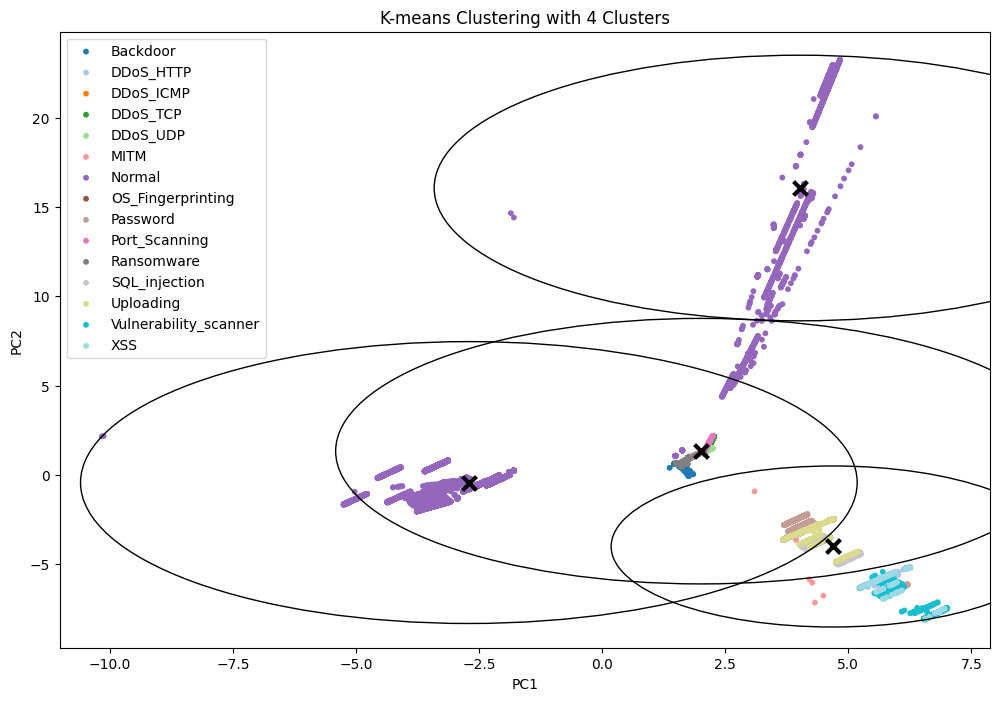

In [14]:
kmeans_clusters_analysis(X_train_scaled, y_train, n_clusters=4)

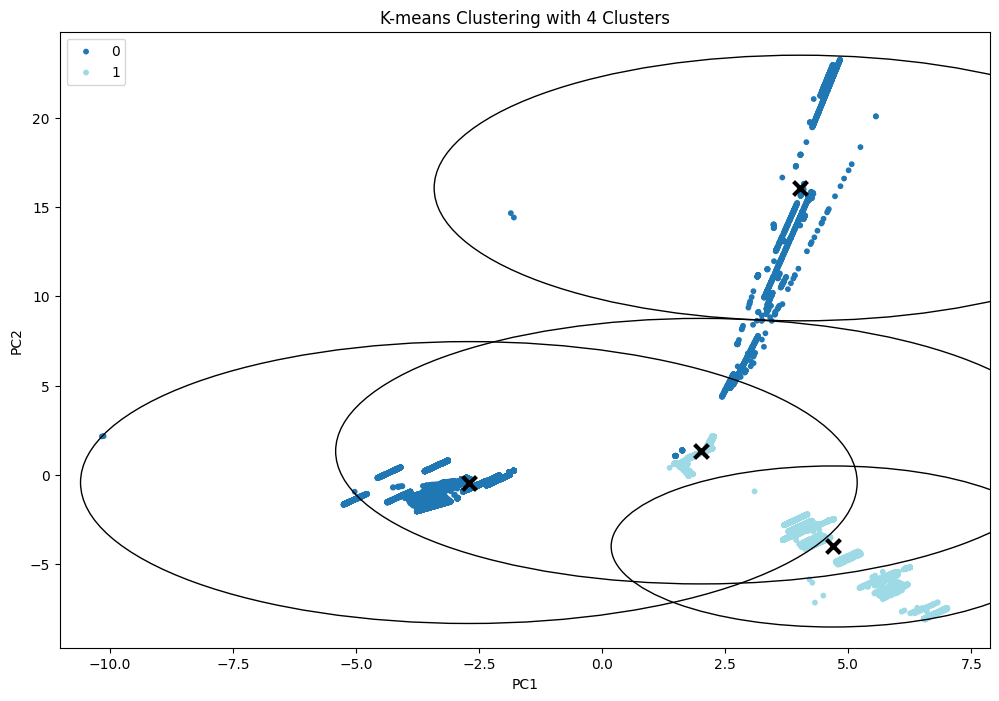

In [15]:
kmeans_clusters_analysis(X_train_scaled, y_isattack, n_clusters=4)

## Gaussian Naive Bayes

GNB is a simple and fast classification algorithm that is suitable for high-dimensional data. It is based on Bayes' theorem and assumes that the features are independent of each other. It is a good choice for text classification tasks that have a large number of features.

Bayes' theorem is given by:

P(A|B) = P(B|A) * P(A) / P(B)

Where:

- P(A|B) is the probability of A given B (posterior probability)
- P(B|A) is the probability of B given A (likelihood)
- P(A) is the probability of A (prior probability)
- P(B) is the probability of B (evidence)

In [16]:
def gnb_analysis(X_train, y_train, X_test, y_test):
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)

    print(
        f"GNB Score: {round(100 * f1_score(y_test, y_pred, average='weighted'), 2)}%\n"
    )
    print(classification_report(y_test, y_pred))

In [17]:
gnb_analysis(X_train_scaled, y_train, X_test_scaled, y_test)

GNB Score: 88.97%



                       precision    recall  f1-score   support

             Backdoor       0.78      0.34      0.47        82
            DDoS_HTTP       0.83      0.99      0.90       749
            DDoS_ICMP       0.99      1.00      1.00       451
             DDoS_TCP       1.00      0.58      0.74      6963
             DDoS_UDP       1.00      1.00      1.00     11138
                 MITM       1.00      1.00      1.00         1
               Normal       1.00      1.00      1.00     24046
    OS_Fingerprinting       0.00      0.00      0.00         4
             Password       1.00      0.12      0.21      3612
        Port_Scanning       0.02      1.00      0.05        75
           Ransomware       0.43      0.12      0.19        24
        SQL_injection       0.06      0.91      0.11       173
            Uploading       0.06      0.37      0.10       124
Vulnerability_scanner       1.00      0.72      0.84       500
                  XSS       0.13      0.12      0.13  

# Random Forest Classifier

RF is a popular ensemble learning algorithm that can be used for classification tasks. It is based on the concept of bagging, which is an ensemble learning technique that combines multiple models to improve the performance of the model. RF builds multiple decision trees and combines them to get a more accurate and stable prediction.

Imagine you have a dataset with 1000 rows and 10 columns. RF will create multiple decision trees using a subset of the data and features. It will then combine the predictions of the individual trees to get the final prediction.

In [18]:
def random_forest_analysis(X_train, y_train, X_test, y_test, n_estimators=100):
    rfc = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)
    accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
    f1 = round(f1_score(y_test, y_pred, average="weighted") * 100, 2)
    print(f"Random Forest Classifier Accuracy: {accuracy}%")
    print(f"Random Forest Classifier F1 Score: {f1}%")
    return rfc

## Feature Importance

We will analyze the feature importance of the RF model to understand which features are important for the prediction. This will help us understand which features are contributing the most to the prediction and which features are not important. This can be used for further analysis and feature selection.

In [19]:
def feature_importance(rfc, X_train):
    feature_importances = rfc.feature_importances_
    feature_importance_df = pd.DataFrame(
        {"Feature": X_train.columns, "Importance": feature_importances}
    )
    feature_importance_df = feature_importance_df.sort_values(
        "Importance", ascending=False
    )
    return feature_importance_df


rfc = random_forest_analysis(X_train_scaled, y_train, X_test_scaled, y_test)

rf_feature_importance = feature_importance(rfc, X_train)

print(rf_feature_importance)

Random Forest Classifier Accuracy: 99.54%
Random Forest Classifier F1 Score: 99.53%
                                Feature  Importance
19                           udp.stream    0.120332
74                   mqtt.protoname_0.0    0.086221
9                           tcp.ack_raw    0.074411
69                mqtt.conack.flags_0.0    0.071866
77                       mqtt.topic_0.0    0.061188
..                                  ...         ...
80                mqtt.topic_Heart_Rate    0.000000
82             mqtt.topic_Soil_Moisture    0.000000
84  mqtt.topic_Temperature_and_Humidity    0.000000
85               mqtt.topic_Water_Level    0.000000
86                   mqtt.topic_phValue    0.000000

[87 rows x 2 columns]
